# Compare LV4 history files at the file boundary

Plots time series of `zeta`, `ubar`, `vbar`, `dye_01`, `dye_02` at the center of the domain for two consecutive LV4 history files. The end of file 1 should match the start of file 2.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

f1 = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604060000.nc'
f2 = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604070000.nc'
f0 = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604050000.nc'
f3 = '/dataSIO/PFM_Simulations/Archive/LV4_His/LV4_ocean_his_202604080000.nc'

ds1 = xr.open_dataset(f1, decode_times=True)
ds2 = xr.open_dataset(f2, decode_times=True)
ds0 = xr.open_dataset(f0, decode_times=True)
ds3 = xr.open_dataset(f3, decode_times=True)
print('file 1 (Apr 6):', ds1.sizes)
print('file 2 (Apr 7):', ds2.sizes)
print('file 0 (Apr 5):', ds0.sizes)
print('file 3 (Apr 8):', ds3.sizes)


file 1 (Apr 6): Frozen({'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121})
file 2 (Apr 7): Frozen({'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121})
file 0 (Apr 5): Frozen({'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121})
file 3 (Apr 8): Frozen({'tracer': 4, 'boundary': 4, 's_rho': 10, 's_w': 11, 'eta_rho': 1141, 'xi_rho': 486, 'eta_u': 1141, 'xi_u': 485, 'eta_v': 1140, 'xi_v': 486, 'eta_psi': 1140, 'xi_psi': 485, 'ocean_time': 121})


In [2]:
# pick the center of the domain (rho-grid)
ny_rho = ds1.sizes['eta_rho']
nx_rho = ds1.sizes['xi_rho']
ny_u   = ds1.sizes['eta_u']
nx_u   = ds1.sizes['xi_u']
ny_v   = ds1.sizes['eta_v']
nx_v   = ds1.sizes['xi_v']

jr, ir = ny_rho // 2, nx_rho // 2  # center on rho grid
ju, iu = ny_u   // 2, nx_u   // 2  # center on u  grid
jv, iv = ny_v   // 2, nx_v   // 2  # center on v  grid
print(f'rho center (j,i) = ({jr},{ir});  u center = ({ju},{iu});  v center = ({jv},{iv})')


rho center (j,i) = (570,243);  u center = (570,242);  v center = (570,243)


In [3]:
# Pull point time series. dye/zeta are on rho; ubar on u; vbar on v.
# dye_01 / dye_02 are 4D (ocean_time, s_rho, eta_rho, xi_rho) -- take surface (top sigma layer).
# Hwave is 3D (ocean_time, eta_rho, xi_rho).
def pull(ds):
    out = {}
    out['time']   = ds['ocean_time'].values
    out['zeta']   = ds['zeta'].isel(eta_rho=jr, xi_rho=ir).values
    out['salt']   = ds['salt'].isel(s_rho=-1,eta_rho=jr, xi_rho=ir).values
    out['temp']   = ds['temp'].isel(s_rho=-1,eta_rho=jr, xi_rho=ir).values
    out['vbar']   = ds['vbar'].isel(eta_v=jv, xi_v=iv).values
    out['dye_01'] = ds['dye_01'].isel(s_rho=-1, eta_rho=jr, xi_rho=ir).values
    out['Hwave']  = ds['Hwave'].isel(eta_rho=jr, xi_rho=ir).values
    return out

a = pull(ds1)
b = pull(ds2)
print('file 1 time range:', a['time'][0], '...', a['time'][-1], f"({len(a['time'])} steps)")
print('file 2 time range:', b['time'][0], '...', b['time'][-1], f"({len(b['time'])} steps)")


file 1 time range: 2026-04-06T00:00:00.000000000 ... 2026-04-11T00:00:00.000000000 (121 steps)
file 2 time range: 2026-04-07T00:00:00.000000000 ... 2026-04-12T00:00:00.000000000 (121 steps)


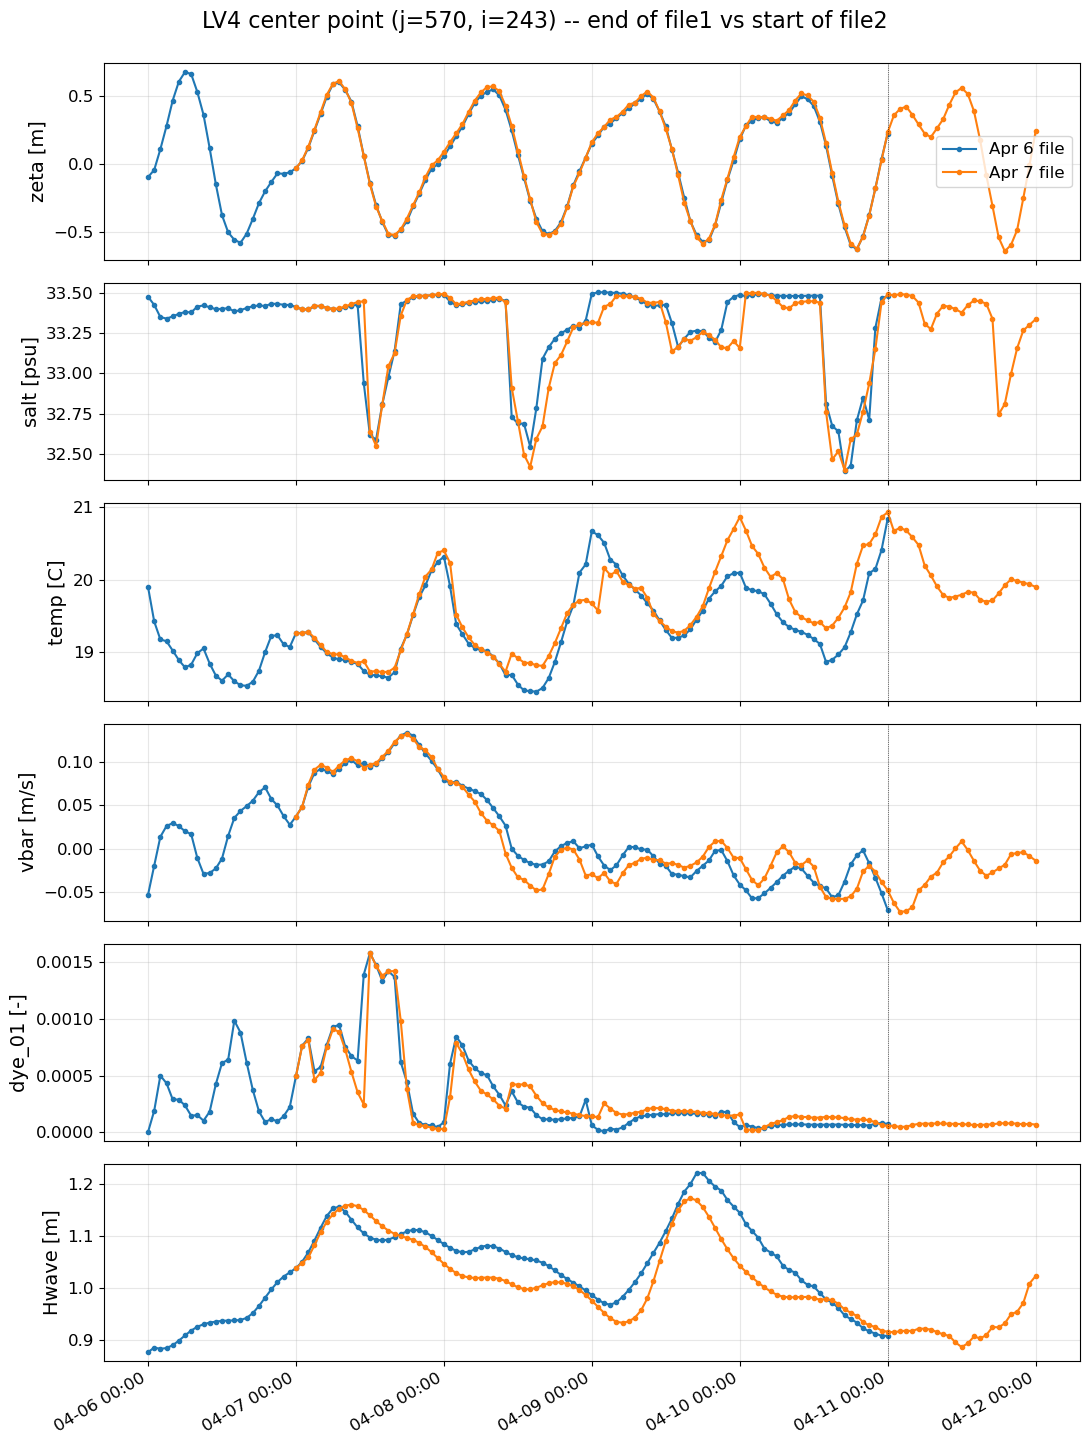

In [4]:
vars_to_plot = ['zeta','salt','temp','vbar','dye_01','Hwave']
units = {'zeta':'m','salt':'psu','temp':'C','vbar':'m/s','dye_01':'-','Hwave':'m'}

c1 = 'tab:blue'   # file 1 (Apr 6)
c2 = 'tab:orange' # file 2 (Apr 7)

LBL_FS = 14
TICK_FS = 12
LEG_FS = 12
TITLE_FS = 16

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(11, 2.4*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(a['time'], a[v], '-o', ms=3, color=c1, label='Apr 6 file')
    ax.plot(b['time'], b[v], '-o', ms=3, color=c2, label='Apr 7 file')
    ax.axvline(a['time'][-1], color='k', lw=0.5, ls=':')
    ax.set_ylabel(f'{v} [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=LEG_FS)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'LV4 center point (j={jr}, i={ir}) -- end of file1 vs start of file2', y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


file 0 (Apr 5) time range: 2026-04-05T00:00:00.000000000 ... 2026-04-10T00:00:00.000000000 (121 steps)
file 3 (Apr 8) time range: 2026-04-08T00:00:00.000000000 ... 2026-04-13T00:00:00.000000000 (121 steps)


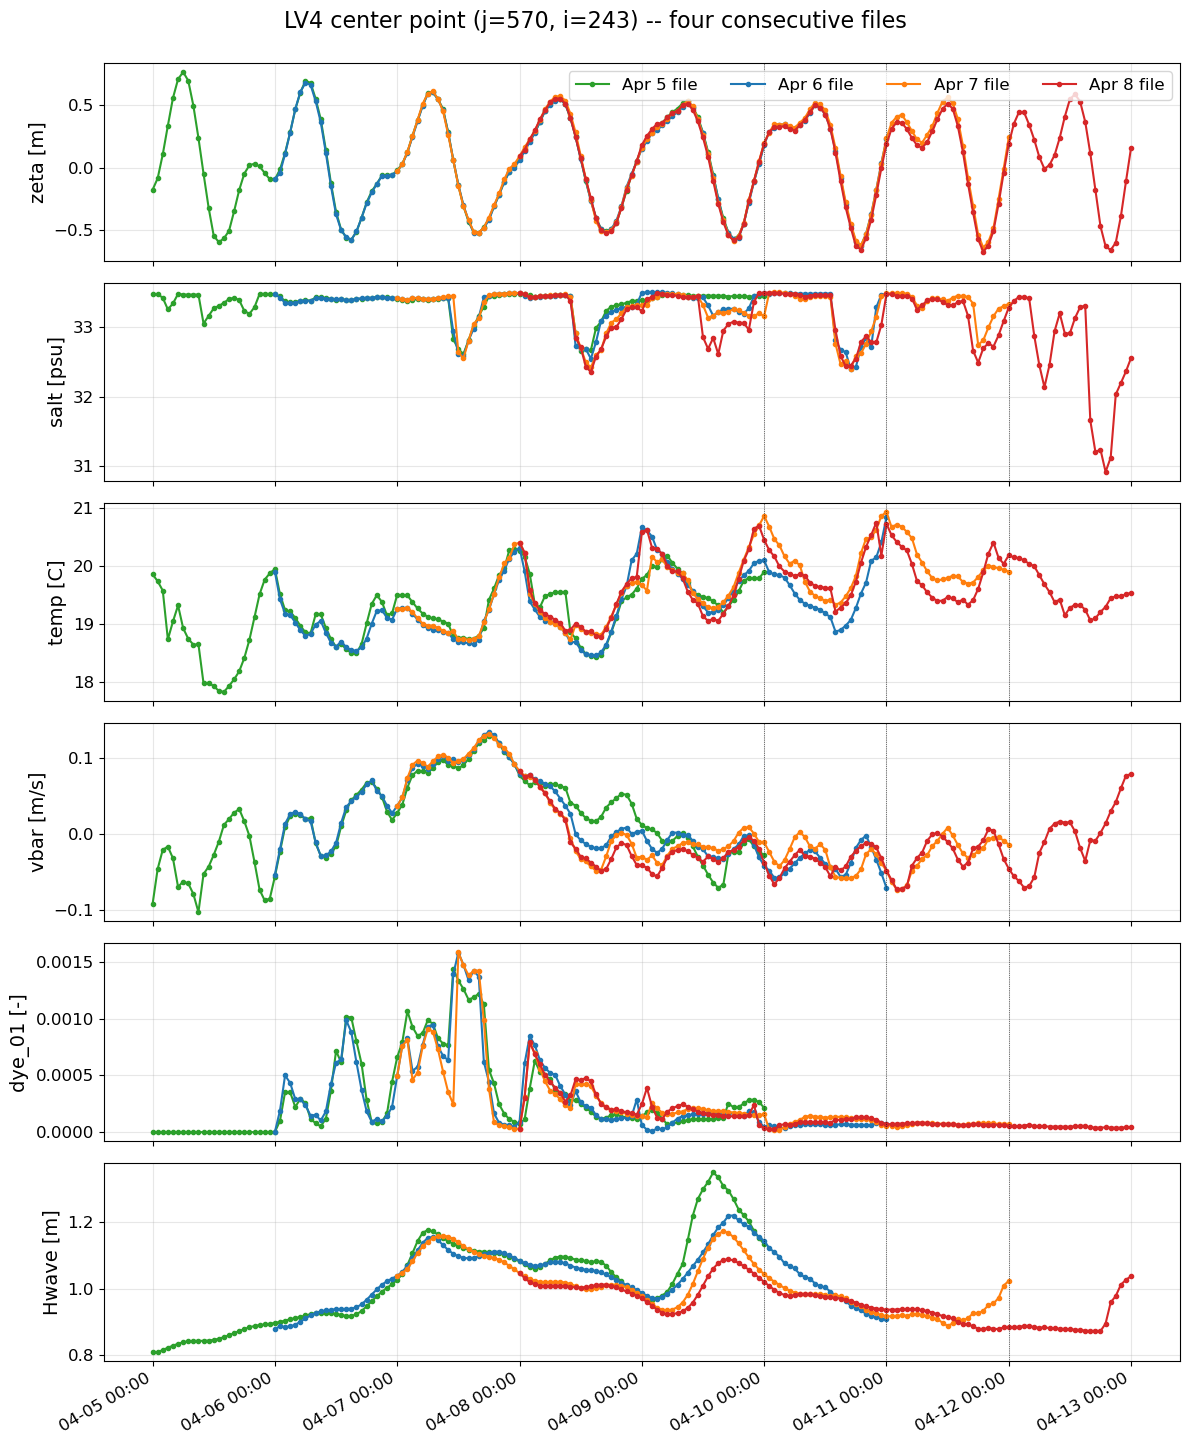

In [5]:
vars_to_plot = ['zeta','salt','temp','vbar','dye_01','Hwave']
units = {'zeta':'m','salt':'psu','temp':'C','vbar':'m/s','dye_01':'-','Hwave':'m'}

# pull the two extra files
c = pull(ds0)  # Apr 5
d = pull(ds3)  # Apr 8
print('file 0 (Apr 5) time range:', c['time'][0], '...', c['time'][-1], f"({len(c['time'])} steps)")
print('file 3 (Apr 8) time range:', d['time'][0], '...', d['time'][-1], f"({len(d['time'])} steps)")

c0_clr = 'tab:green'  # file 0 (Apr 5)
c1_clr = 'tab:blue'   # file 1 (Apr 6)
c2_clr = 'tab:orange' # file 2 (Apr 7)
c3_clr = 'tab:red'    # file 3 (Apr 8)

LBL_FS = 14
TICK_FS = 12
LEG_FS = 12
TITLE_FS = 16

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.4*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(c['time'], c[v], '-o', ms=3, color=c0_clr, label='Apr 5 file')
    ax.plot(a['time'], a[v], '-o', ms=3, color=c1_clr, label='Apr 6 file')
    ax.plot(b['time'], b[v], '-o', ms=3, color=c2_clr, label='Apr 7 file')
    ax.plot(d['time'], d[v], '-o', ms=3, color=c3_clr, label='Apr 8 file')
    for t in (c['time'][-1], a['time'][-1], b['time'][-1]):
        ax.axvline(t, color='k', lw=0.5, ls=':')
    ax.set_ylabel(f'{v} [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=LEG_FS, ncol=4)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'LV4 center point (j={jr}, i={ir}) -- four consecutive files', y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


Apr 4: 2026-04-04T00:00:00.000000000 ... 2026-04-09T00:00:00.000000000 (121 steps)
Apr 5: 2026-04-05T00:00:00.000000000 ... 2026-04-10T00:00:00.000000000 (121 steps)
Apr 6: 2026-04-06T00:00:00.000000000 ... 2026-04-11T00:00:00.000000000 (121 steps)
Apr 7: 2026-04-07T00:00:00.000000000 ... 2026-04-12T00:00:00.000000000 (121 steps)
Apr 8: 2026-04-08T00:00:00.000000000 ... 2026-04-13T00:00:00.000000000 (121 steps)
Apr 9: 2026-04-09T00:00:00.000000000 ... 2026-04-14T00:00:00.000000000 (121 steps)
Apr 10: 2026-04-10T00:00:00.000000000 ... 2026-04-15T00:00:00.000000000 (121 steps)
Apr 11: 2026-04-11T00:00:00.000000000 ... 2026-04-16T00:00:00.000000000 (121 steps)
Apr 12: 2026-04-12T00:00:00.000000000 ... 2026-04-17T00:00:00.000000000 (121 steps)
Apr 13: 2026-04-13T00:00:00.000000000 ... 2026-04-18T00:00:00.000000000 (121 steps)
Apr 14: 2026-04-14T00:00:00.000000000 ... 2026-04-19T00:00:00.000000000 (121 steps)
Apr 15: 2026-04-15T00:00:00.000000000 ... 2026-04-20T00:00:00.000000000 (121 steps

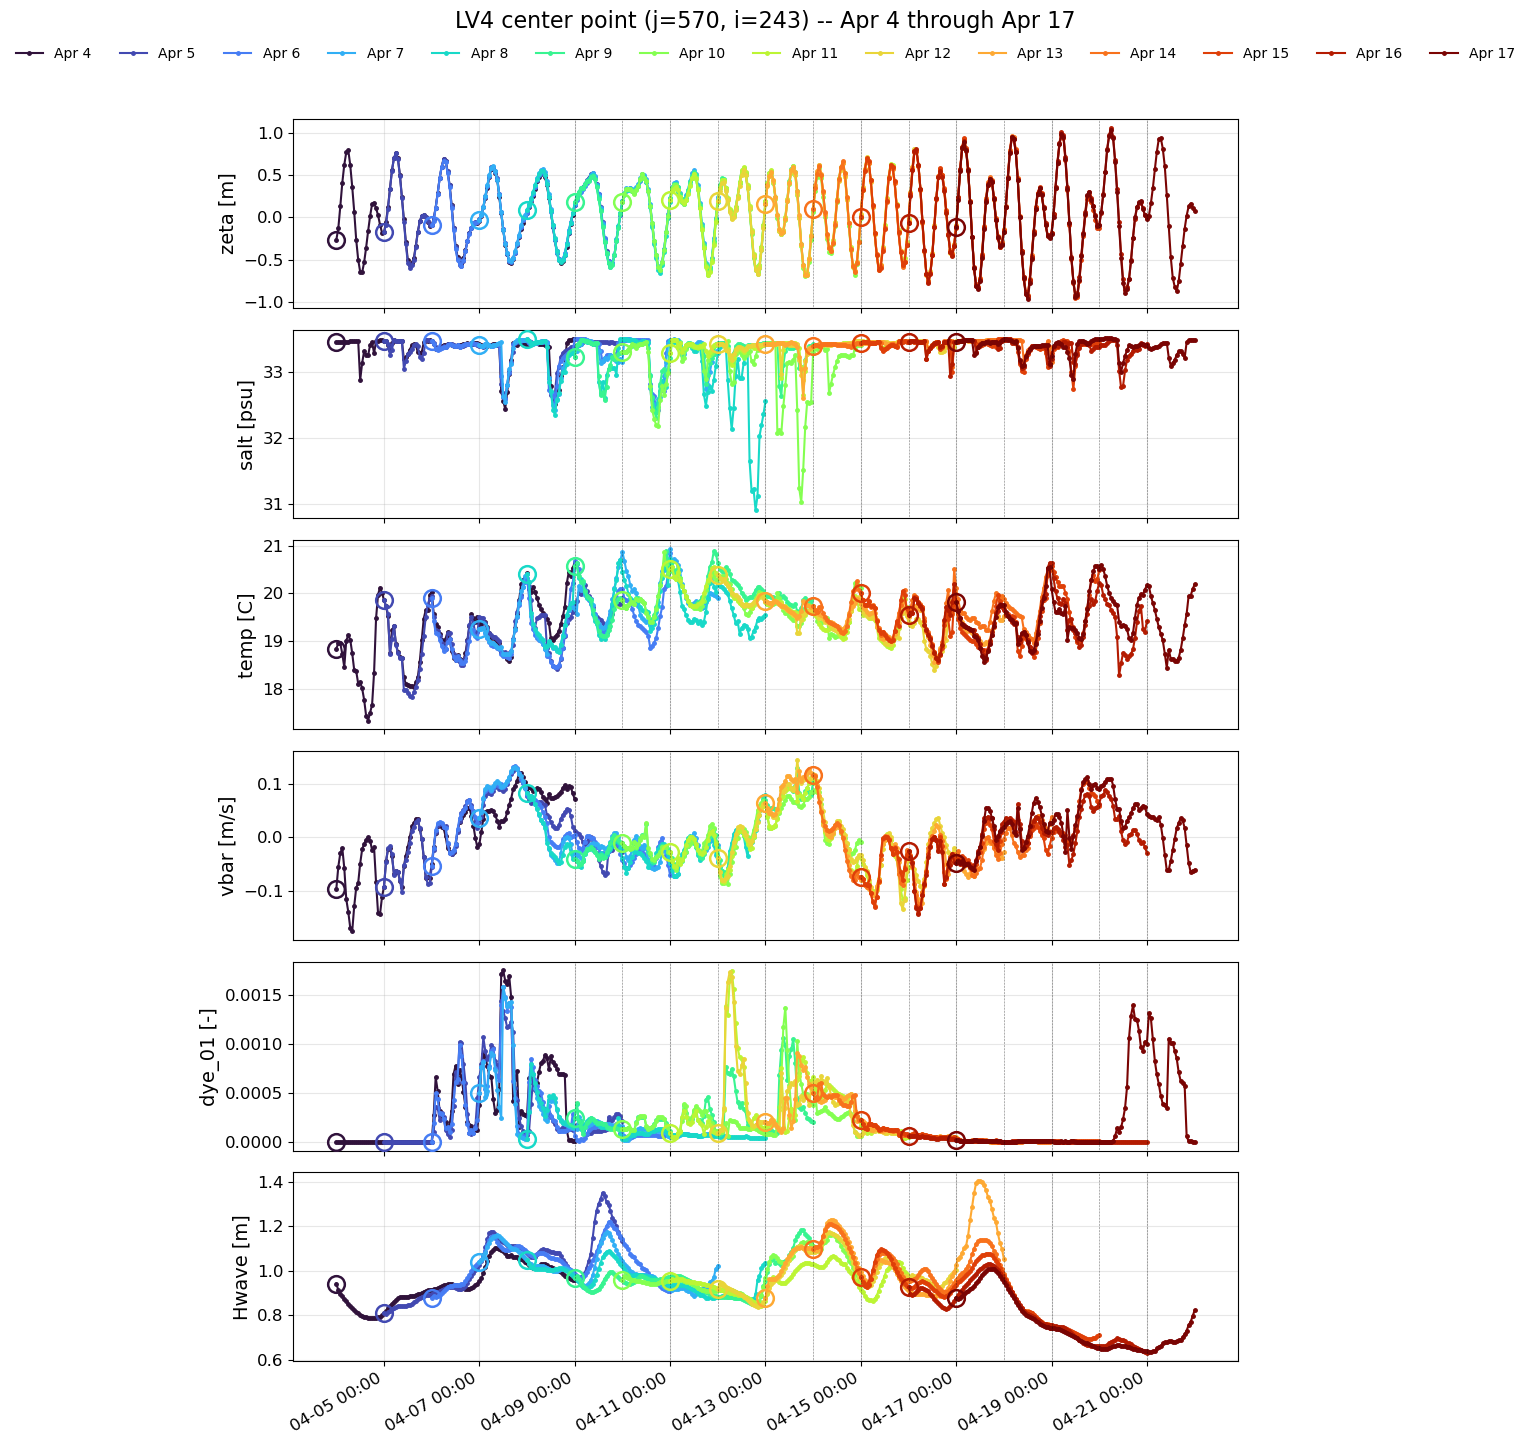

In [6]:
# Plot Apr 4 through Apr 17 (13 files)
his_dir = '/dataSIO/PFM_Simulations/Archive/LV4_His'
days = list(range(4, 18))  # 5..17 inclusive
files = [(f'Apr {d}', f'{his_dir}/LV4_ocean_his_202604{d:02d}0000.nc') for d in days]

# load + pull
series = []
for label, fn in files:
    ds = xr.open_dataset(fn, decode_times=True)
    s  = pull(ds)
    s['label'] = label
    series.append(s)
    print(f"{label}: {s['time'][0]} ... {s['time'][-1]} ({len(s['time'])} steps)")

vars_to_plot = ['zeta','salt','temp','vbar','dye_01','Hwave']
units = {'zeta':'m','salt':'psu','temp':'C','vbar':'m/s','dye_01':'-','Hwave':'m'}

LBL_FS = 14
TICK_FS = 12
LEG_FS = 10
TITLE_FS = 16

# distinct color per file
cmap = plt.get_cmap('turbo')
colors = [cmap(i/(len(series)-1)) for i in range(len(series))]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 2.4*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    for s, clr in zip(series, colors):
        ax.plot(s['time'], s[v], '-o', ms=2.5, color=clr, label=s['label'])
    # mark the first data point of each file with a large open circle
    for s, clr in zip(series, colors):
        ax.plot(s['time'][0], s[v][0], 'o', ms=12, mec=clr,
                mfc='none', mew=1.8, zorder=5)
    # seam markers between consecutive files
    for s in series[:-1]:
        ax.axvline(s['time'][-1], color='k', lw=0.4, ls=':')
    ax.set_ylabel(f'{v} [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.45), fontsize=LEG_FS,
               ncol=len(series), frameon=False)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'LV4 center point (j={jr}, i={ir}) -- Apr 4 through Apr 17', y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()


Apr 4: 2026-04-04T00:00:00.000000000 ... 2026-04-09T00:00:00.000000000 (121 steps)
Apr 5: 2026-04-05T00:00:00.000000000 ... 2026-04-10T00:00:00.000000000 (121 steps)
Apr 6: 2026-04-06T00:00:00.000000000 ... 2026-04-11T00:00:00.000000000 (121 steps)
Apr 7: 2026-04-07T00:00:00.000000000 ... 2026-04-12T00:00:00.000000000 (121 steps)
Apr 8: 2026-04-08T00:00:00.000000000 ... 2026-04-13T00:00:00.000000000 (121 steps)
Apr 9: 2026-04-09T00:00:00.000000000 ... 2026-04-14T00:00:00.000000000 (121 steps)
Apr 10: 2026-04-10T00:00:00.000000000 ... 2026-04-15T00:00:00.000000000 (121 steps)
Apr 11: 2026-04-11T00:00:00.000000000 ... 2026-04-16T00:00:00.000000000 (121 steps)
Apr 12: 2026-04-12T00:00:00.000000000 ... 2026-04-17T00:00:00.000000000 (121 steps)
Apr 13: 2026-04-13T00:00:00.000000000 ... 2026-04-18T00:00:00.000000000 (121 steps)
Apr 14: 2026-04-14T00:00:00.000000000 ... 2026-04-19T00:00:00.000000000 (121 steps)
Apr 15: 2026-04-15T00:00:00.000000000 ... 2026-04-20T00:00:00.000000000 (121 steps

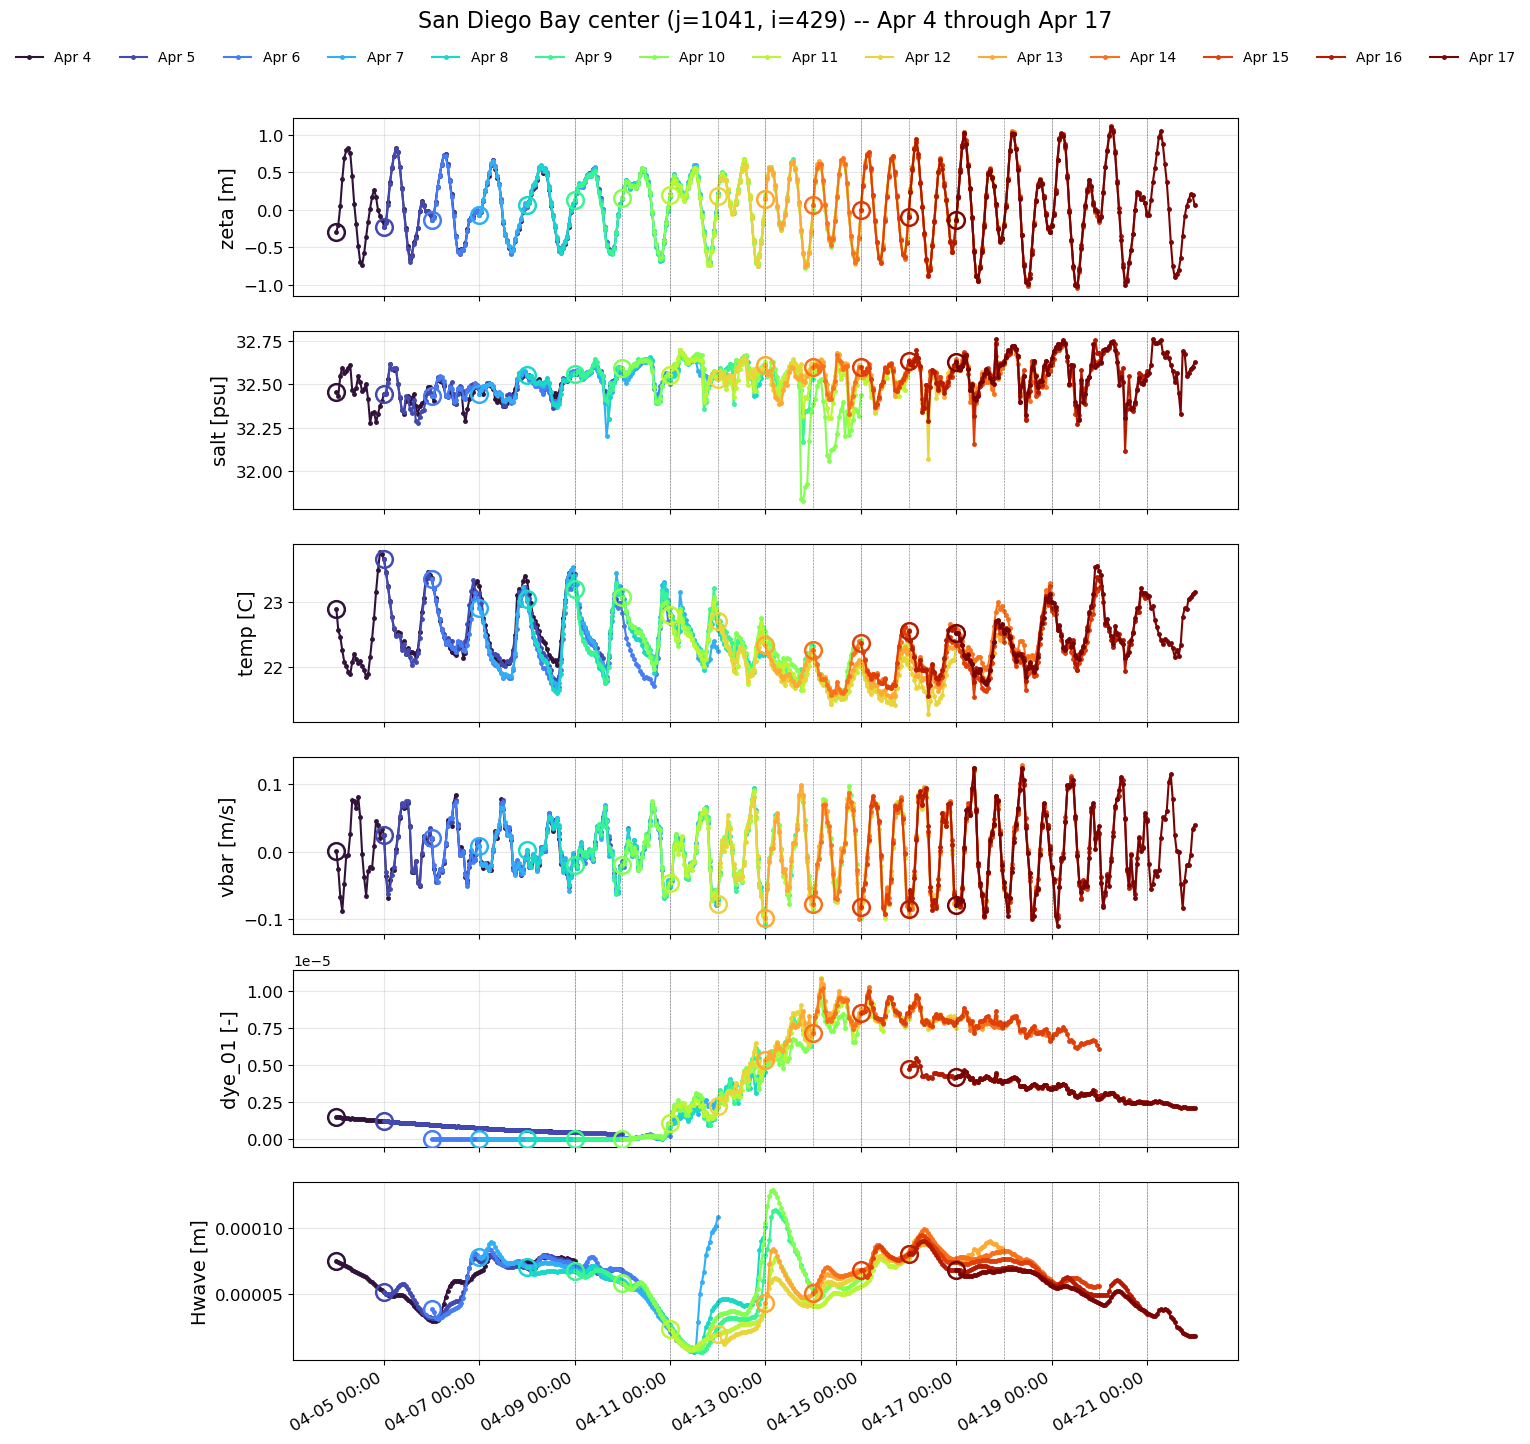

: 

In [ ]:
# Same as the previous cell, but at the CENTER OF SAN DIEGO BAY (lon~-117.135, lat~32.683)
his_dir = '/dataSIO/PFM_Simulations/Archive/LV4_His'
days = list(range(4, 18))  # Apr 4..17 inclusive
files = [(f'Apr {d}', f'{his_dir}/LV4_ocean_his_202604{d:02d}0000.nc') for d in days]

# SD Bay center indices (computed by finding the rho-grid point nearest 32.683 N, -117.135 W
# in /scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc)
jr_sd, ir_sd = 1041, 429
ju_sd, iu_sd = 1041, 429
jv_sd, iv_sd = 1041, 429

# local pull function bound to the SD-Bay indices (does not change cell-6's globals)
def pull_sd(ds):
    return {
        'time':   ds['ocean_time'].values,
        'zeta':   ds['zeta'].isel(eta_rho=jr_sd, xi_rho=ir_sd).values,
        'ubar':   ds['ubar'].isel(eta_u=ju_sd,   xi_u=iu_sd).values,
        'vbar':   ds['vbar'].isel(eta_v=jv_sd,   xi_v=iv_sd).values,
        'temp':   ds['temp'].isel(s_rho=-1, eta_rho=jr_sd, xi_rho=ir_sd).values,
        'salt':   ds['salt'].isel(s_rho=-1, eta_rho=jr_sd, xi_rho=ir_sd).values,
        'dye_01': ds['dye_01'].isel(s_rho=-1, eta_rho=jr_sd, xi_rho=ir_sd).values,
        'dye_02': ds['dye_02'].isel(s_rho=-1, eta_rho=jr_sd, xi_rho=ir_sd).values,
        'Hwave':  ds['Hwave'].isel(eta_rho=jr_sd, xi_rho=ir_sd).values,
    }

series = []
for label, fn in files:
    ds = xr.open_dataset(fn, decode_times=True)
    s  = pull_sd(ds)
    s['label'] = label
    series.append(s)
    print(f"{label}: {s['time'][0]} ... {s['time'][-1]} ({len(s['time'])} steps)")

vars_to_plot = ['zeta','salt','temp','vbar','dye_01','Hwave']
units = {'zeta':'m','salt':'psu','temp':'C','vbar':'m/s','dye_01':'-','Hwave':'m'}

LBL_FS = 14
TICK_FS = 12
LEG_FS = 10
TITLE_FS = 16

# distinct color per file
cmap = plt.get_cmap('turbo')
colors = [cmap(i/(len(series)-1)) for i in range(len(series))]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 2.4*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    for s, clr in zip(series, colors):
        ax.plot(s['time'], s[v], '-o', ms=2.5, color=clr, label=s['label'])
    # mark the first data point of each file with a large open circle
    for s, clr in zip(series, colors):
        ax.plot(s['time'][0], s[v][0], 'o', ms=12, mec=clr,
                mfc='none', mew=1.8, zorder=5)
    # seam markers between consecutive files
    for s in series[:-1]:
        ax.axvline(s['time'][-1], color='k', lw=0.4, ls=':')
    ax.set_ylabel(f'{v} [{units[v]}]', fontsize=LBL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.45), fontsize=LEG_FS,
               ncol=len(series), frameon=False)
axes[-1].xaxis.set_major_formatter(DateFormatter('%m-%d %H:%M'))
fig.autofmt_xdate()
fig.suptitle(f'San Diego Bay center (j={jr_sd}, i={ir_sd}) -- Apr 4 through Apr 17',
             y=1.0, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()
